In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [9]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (50000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


In [10]:
# CIFAR-10: cat = 3, dog = 5
train_mask = np.isin(y_train.flatten(), [3, 5])
test_mask = np.isin(y_test.flatten(), [3, 5])

x_train_bin = x_train[train_mask]
y_train_bin = y_train[train_mask].flatten()

x_test_bin = x_test[test_mask]
y_test_bin = y_test[test_mask].flatten()

# Cat = 0, Dog = 1
y_train_bin = (y_train_bin == 5).astype(int)
y_test_bin = (y_test_bin == 5).astype(int)

print("Binary training:", x_train_bin.shape)
print("Binary testing:", x_test_bin.shape)

Binary training: (10000, 32, 32, 3)
Binary testing: (2000, 32, 32, 3)


In [11]:
x_train_bin = x_train_bin / 255.0
x_test_bin = x_test_bin / 255.0

In [12]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    x_train_bin,
    y_train_bin,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.5592 - loss: 0.6790 - val_accuracy: 0.6325 - val_loss: 0.6579
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.6276 - loss: 0.6381 - val_accuracy: 0.6650 - val_loss: 0.6099
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.6706 - loss: 0.6020 - val_accuracy: 0.6815 - val_loss: 0.5960
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.6896 - loss: 0.5776 - val_accuracy: 0.7045 - val_loss: 0.5779
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.7110 - loss: 0.5559 - val_accuracy: 0.6920 - val_loss: 0.5704
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.7218 - loss: 0.5415 - val_accuracy: 0.7110 - val_loss: 0.5547
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.7300 - loss: 0.5302 - val_accuracy: 0.6985 - val_loss: 0.5613
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.7414 - loss: 0.5158 -

In [7]:
loss, accuracy = model.evaluate(x_test_bin, y_test_bin)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7470 - loss: 0.5041
Test Loss: 0.5041260719299316
Test Accuracy: 0.746999979019165


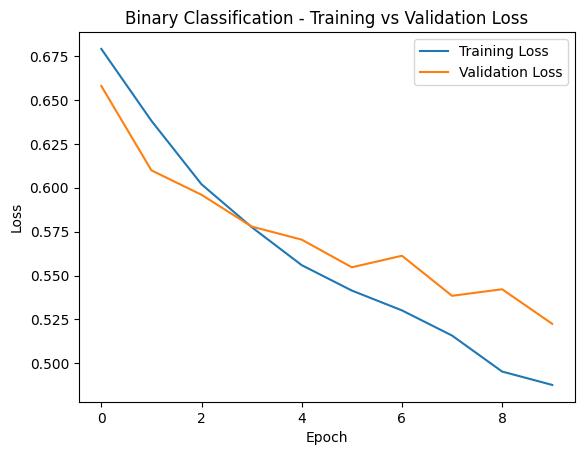

In [13]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Binary Classification - Training vs Validation Loss')
plt.legend()
plt.show()

In [14]:
x_train_multi = x_train / 255.0
x_test_multi = x_test / 255.0

y_train_multi = y_train.flatten()
y_test_multi = y_test.flatten()

print("Training data:", x_train_multi.shape)
print("Testing data:", x_test_multi.shape)

Training data: (50000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


In [15]:
model_multi = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_multi.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_multi.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_multi = model_multi.fit(
    x_train_multi,
    y_train_multi,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 96ms/step - accuracy: 0.4058 - loss: 1.6311 - val_accuracy: 0.5287 - val_loss: 1.3260
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 89ms/step - accuracy: 0.5422 - loss: 1.2958 - val_accuracy: 0.5965 - val_loss: 1.1627
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 86ms/step - accuracy: 0.5874 - loss: 1.1717 - val_accuracy: 0.6194 - val_loss: 1.0999
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.6137 - loss: 1.1006 - val_accuracy: 0.6411 - val_loss: 1.0357
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 85ms/step - accuracy: 0.6360 - loss: 1.0457 - val_accuracy: 0.6475 - val_loss: 1.0115
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 88ms/step - accuracy: 0.6453 - loss: 1.0072 - val_accuracy: 0.6616 - val_loss: 0.9758
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.6622 - loss: 0.9633 - val_accuracy: 0.6866 - val_loss: 0.9252
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.6728 - loss: 0.9360 - 

In [17]:
loss, accuracy = model_multi.evaluate(
    x_test_multi,
    y_test_multi
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6952 - loss: 0.8860
Test Loss: 0.885973334312439
Test Accuracy: 0.6952000260353088


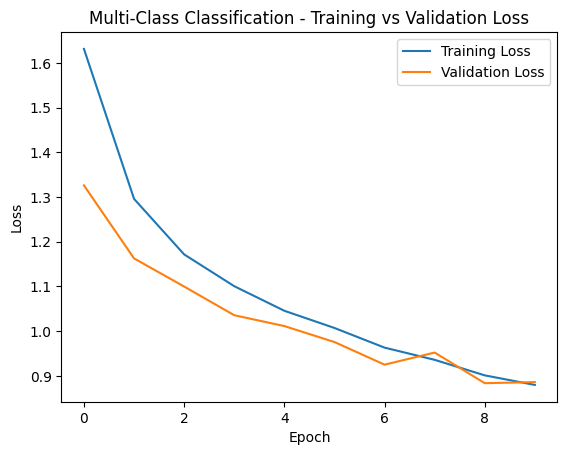

In [18]:
plt.plot(history_multi.history['loss'], label='Training Loss')
plt.plot(history_multi.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Multi-Class Classification - Training vs Validation Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


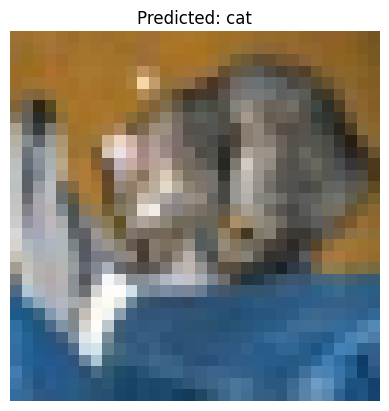

In [19]:
classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

prediction = model_multi.predict(x_test_multi[:1])
predicted_class = np.argmax(prediction)

plt.imshow(x_test[0])
plt.title("Predicted: " + classes[predicted_class])
plt.axis('off')
plt.show()